# Source MAP Training on UCI HAR (TODO.md §4)

Train a 3-class locomotion classifier on the source pool, evaluate on source validation and per-target-subject, then fit the last-layer Laplace approximation.

**Architecture:** 561 → 128 → 64 → 3 (FeatureClassifier)  
**Task:** WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS  
**Training:** AdamW + cross-entropy on source pool (with class weights if needed)  
**Validation:** Subject-wise split within source pool  
**Evaluation:** Per-subject accuracy + macro-recall on all target subjects

## Setup

In [1]:
import sys
from pathlib import Path

# Add parent directory to path
root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.loader import load_har, LOCOMOTION_IDS
from src.subject_split import split_and_scale
from src.bayesian import FeatureClassifier, LastLayerLaplace
from src.har_train import (
    subject_train_val_split,
    check_class_balance,
    train_source_model,
    evaluate_per_subject
)

torch.manual_seed(42)
np.random.seed(42)

print("✓ Imports successful")

✓ Imports successful


## 1. Load Data and Source/Target Split

In [2]:
# Load full UCI HAR dataset, filter for 3-class locomotion
dataset_full = load_har("../data", merge_train_test=True)
dataset = dataset_full.filter_activities(LOCOMOTION_IDS)

print(f"Full dataset: {dataset_full.X.shape[0]} samples")
print(f"Locomotion only: {dataset.X.shape[0]} samples")
print(f"Features: {dataset.X.shape[1]}")
print(f"Classes: {len(LOCOMOTION_IDS)} (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS)")
print(f"\nActivity distribution:")
for activity_id in LOCOMOTION_IDS:
    count = (dataset.y == activity_id).sum()
    print(f"  {activity_id}: {count} samples")

Full dataset: 10299 samples
Locomotion only: 4672 samples
Features: 561
Classes: 3 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS)

Activity distribution:
  1: 1722 samples
  2: 1544 samples
  3: 1406 samples


In [3]:
# Source/target split (20 source subjects, 10 target subjects)
# This also fits the scaler on source pool only
split = split_and_scale(dataset, n_source=20, seed=42)

print("\nSource/Target Split:")
print("=" * 60)
print(f"Source subjects ({len(split.source_subjects)}): {split.source_subjects}")
print(f"Target subjects ({len(split.target_subjects)}): {split.target_subjects}")
print(f"\nSource pool: {split.X_source.shape[0]} samples (scaled)")
print(f"Scaler fit on source pool only: ✓")


Source/Target Split:
Source subjects (20): [ 1  2  3  4  5  6  9 10 12 13 14 16 17 18 23 24 25 26 28 29]
Target subjects (10): [ 7  8 11 15 19 20 21 22 27 30]

Source pool: 3197 samples (scaled)
Scaler fit on source pool only: ✓


## 2. Train/Val Split Within Source Pool (Subject-wise)

In [4]:
# Split source subjects into train/val (80/20)
train_subjects, val_subjects = subject_train_val_split(split.source_subjects,
                                                       val_fraction=0.2, seed=42)

print("Source pool train/val split (subject-wise):")
print("=" * 60)
print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Val subjects ({len(val_subjects)}): {val_subjects}")
print(f"\nSplit ratio: {len(train_subjects)}/{len(val_subjects)} = "
      f"{len(train_subjects)/(len(train_subjects)+len(val_subjects)):.1%} train")

# Filter source data by train/val subjects
train_mask = np.isin(split.subject_id_source, train_subjects)
val_mask = np.isin(split.subject_id_source, val_subjects)

X_train = torch.tensor(split.X_source[train_mask], dtype=torch.float32)
y_train_raw = split.y_source[train_mask]
X_val = torch.tensor(split.X_source[val_mask], dtype=torch.float32)
y_val_raw = split.y_source[val_mask]

print(f"\nTrain samples: {X_train.shape[0]}")
print(f"Val samples: {X_val.shape[0]}")

Source pool train/val split (subject-wise):
Train subjects (16): [ 3  4  5  6  9 10 12 13 14 16 17 18 23 25 28 29]
Val subjects (4): [ 1  2 24 26]

Split ratio: 16/4 = 80.0% train

Train samples: 2510
Val samples: 687


## 3. Remap Labels to 0-2 for 3-class Classification

In [5]:
# Original labels: 1=WALKING, 2=WALKING_UPSTAIRS, 3=WALKING_DOWNSTAIRS
# Remap to: 0, 1, 2 for nn.CrossEntropyLoss
label_map = {1: 0, 2: 1, 3: 2}
y_train = torch.tensor([label_map[y] for y in y_train_raw], dtype=torch.long)
y_val = torch.tensor([label_map[y] for y in y_val_raw], dtype=torch.long)

print("Label remapping (original -> model):")
for orig, new in label_map.items():
    activity_name = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS'}[orig]
    print(f"  {orig} ({activity_name}) -> {new}")

print(f"\nRemapped labels range: [{y_train.min()}, {y_train.max()}]")
assert y_train.min() == 0 and y_train.max() == 2, "Labels should be 0-2"

Label remapping (original -> model):
  1 (WALKING) -> 0
  2 (WALKING_UPSTAIRS) -> 1
  3 (WALKING_DOWNSTAIRS) -> 2

Remapped labels range: [0, 2]


## 4. Check Class Balance in Source Train Set

In [6]:
# Check if class weighting is needed
class_weights = check_class_balance(y_train.numpy(), n_classes=3,
                                    split_name="source train")

if class_weights is not None:
    print(f"\n→ Will use class weights in CrossEntropyLoss")
else:
    print(f"\n→ No class weights needed")


Class distribution (source train):
  Counts: [910 839 761]
  Frequencies: [0.3625498  0.33426295 0.30318725]
  Imbalance ratio (max/min): 1.20
  Classes reasonably balanced, no weighting needed

→ No class weights needed


## 5. Initialize Model

In [7]:
# Architecture: 561 -> 128 -> 64 -> 3
model = FeatureClassifier(in_dim=561, hidden_dims=[128, 64], n_classes=3)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_params_g = sum(p.numel() for p in model.g.parameters())
n_params_h = sum(p.numel() for p in model.h.parameters())

print("Model architecture:")
print(f"  Feature extractor (g): 561 -> 128 -> 64")
print(f"  Linear head (h): 64 -> 3")
print(f"\nParameters:")
print(f"  Total: {n_params:,}")
print(f"  Feature extractor: {n_params_g:,}")
print(f"  Head: {n_params_h:,}")
print(f"\nModel: {model}")

Model architecture:
  Feature extractor (g): 561 -> 128 -> 64
  Linear head (h): 64 -> 3

Parameters:
  Total: 80,387
  Feature extractor: 80,192
  Head: 195

Model: FeatureClassifier(
  (g): Sequential(
    (0): Linear(in_features=561, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (h): Linear(in_features=64, out_features=3, bias=True)
)


## 6. Train Source Model

In [8]:
# Train with AdamW + early stopping on val loss
history = train_source_model(
    model, X_train, y_train, X_val, y_val,
    weight_decay=0.01,
    lr=1e-3,
    epochs=200,
    class_weights=class_weights,
    patience=20
)

print(f"\n✓ Training complete")
print(f"  Best epoch: {history['best_epoch']}")
print(f"  tau_prior (weight_decay * N_train): {history['tau_prior']:.2f}")


Training configuration:
  Optimizer: AdamW
  Learning rate: 0.001
  Weight decay: 0.01
  tau_prior (weight_decay * N_train): 25.10
  Max epochs: 200
  Early stopping patience: 20
  Train samples: 2510, Val samples: 687
Epoch   1/200: train_loss=1.0916 train_acc=0.284 train_recall=0.277 | val_loss=0.9861 val_acc=0.783 val_recall=0.773 | patience=0/20
Epoch  10/200: train_loss=0.4553 train_acc=0.880 train_recall=0.877 | val_loss=0.3723 val_acc=0.948 val_recall=0.942 | patience=0/20
Epoch  20/200: train_loss=0.1321 train_acc=0.973 train_recall=0.972 | val_loss=0.1741 val_acc=0.946 val_recall=0.942 | patience=0/20
Epoch  30/200: train_loss=0.0358 train_acc=0.995 train_recall=0.995 | val_loss=0.0863 val_acc=0.971 val_recall=0.969 | patience=2/20
Epoch  40/200: train_loss=0.0136 train_acc=0.998 train_recall=0.998 | val_loss=0.0592 val_acc=0.977 val_recall=0.975 | patience=0/20
Epoch  50/200: train_loss=0.0056 train_acc=0.998 train_recall=0.998 | val_loss=0.0671 val_acc=0.965 val_recall=0.96

## 7. Training Curves

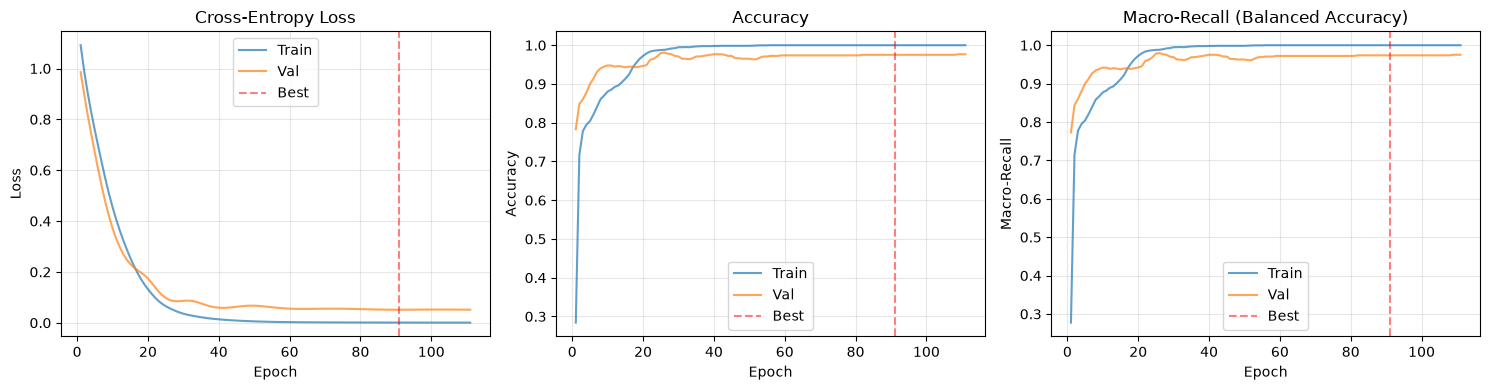

Final metrics at best epoch (91):
  Train - loss: 0.0009, acc: 1.000, recall: 1.000
  Val   - loss: 0.0513, acc: 0.975, recall: 0.974


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', alpha=0.7)
axes[0].plot(epochs_range, history['val_loss'], label='Val', alpha=0.7)
axes[0].axvline(history['best_epoch'], color='red', linestyle='--', alpha=0.5, label='Best')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', alpha=0.7)
axes[1].plot(epochs_range, history['val_acc'], label='Val', alpha=0.7)
axes[1].axvline(history['best_epoch'], color='red', linestyle='--', alpha=0.5, label='Best')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Macro-Recall
axes[2].plot(epochs_range, history['train_recall'], label='Train', alpha=0.7)
axes[2].plot(epochs_range, history['val_recall'], label='Val', alpha=0.7)
axes[2].axvline(history['best_epoch'], color='red', linestyle='--', alpha=0.5, label='Best')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-Recall')
axes[2].set_title('Macro-Recall (Balanced Accuracy)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final metrics at best epoch ({history['best_epoch']}):")
print(f"  Train - loss: {history['train_loss'][history['best_epoch']-1]:.4f}, "
      f"acc: {history['train_acc'][history['best_epoch']-1]:.3f}, "
      f"recall: {history['train_recall'][history['best_epoch']-1]:.3f}")
print(f"  Val   - loss: {history['val_loss'][history['best_epoch']-1]:.4f}, "
      f"acc: {history['val_acc'][history['best_epoch']-1]:.3f}, "
      f"recall: {history['val_recall'][history['best_epoch']-1]:.3f}")

## 8. Per-Target-Subject Evaluation

**CRITICAL:** Labels are never used for model selection, only for final evaluation reporting.

In [10]:
# Need to create a scaled version of full dataset for target evaluation
# Apply the source scaler to all data
X_all_scaled = split.scaler.transform(dataset.X)

# Create remapped labels for full dataset
y_all_remapped = np.array([label_map[y] for y in dataset.y])

# Create a temporary dataset-like object for evaluation
class EvalDataset:
    def __init__(self, X, y, subject_id):
        self.X = X
        self.y = y
        self.subject_id = subject_id
    
    def filter_subjects(self, sids):
        mask = np.isin(self.subject_id, sids)
        return EvalDataset(self.X[mask], self.y[mask], self.subject_id[mask])

eval_dataset = EvalDataset(X_all_scaled, y_all_remapped, dataset.subject_id)

# Evaluate on each target subject
target_results = evaluate_per_subject(model, eval_dataset, split.target_subjects,
                                     split_name="target")


Per-subject evaluation (target):
  Subject  7: acc=0.935, recall=0.936, n=155
  Subject  8: acc=0.913, recall=0.924, n=127
  Subject 11: acc=0.987, recall=0.989, n=159
  Subject 15: acc=0.993, recall=0.994, n=144
  Subject 19: acc=0.779, recall=0.804, n=131
  Subject 20: acc=0.653, recall=0.643, n=147
  Subject 21: acc=0.979, recall=0.980, n=144
  Subject 22: acc=0.895, recall=0.902, n=124
  Subject 27: acc=1.000, recall=1.000, n=152
  Subject 30: acc=0.995, recall=0.995, n=192
Summary (target):
  Accuracy:     mean=0.913, std=0.108, min=0.653, max=1.000
  Macro-recall: mean=0.917, std=0.108, min=0.643, max=1.000


## 9. Fit Last-Layer Laplace Approximation

In [11]:
# Fit Laplace on full source pool (train + val) using tau_prior from training
X_source_full = torch.tensor(split.X_source, dtype=torch.float32)
y_source_full = torch.tensor([label_map[y] for y in split.y_source], dtype=torch.long)

print("Fitting last-layer Laplace approximation...")
print(f"  Data: {X_source_full.shape[0]} source samples")
print(f"  tau_prior: {history['tau_prior']:.2f}")

laplace = LastLayerLaplace.fit(model, X_source_full, y_source_full,
                               tau_prior=history['tau_prior'])

print(f"\n✓ Laplace fitted")
print(f"  theta_map shape: {laplace.theta_map.shape}")
print(f"  Covariance shape: {laplace.cov.shape}")
print(f"  K={laplace.K}, Dp={laplace.Dp}")

Fitting last-layer Laplace approximation...
  Data: 3197 source samples
  tau_prior: 25.10

✓ Laplace fitted
  theta_map shape: torch.Size([195])
  Covariance shape: torch.Size([195, 195])
  K=3, Dp=65


## 10. Validate Laplace Covariance

In [12]:
# Check covariance matrix validity
eigvals = torch.linalg.eigvalsh(laplace.cov)

print("Covariance matrix validation:")
print("=" * 60)
print(f"  Eigenvalue range: [{eigvals.min():.2e}, {eigvals.max():.2e}]")
print(f"  All positive: {(eigvals > 0).all().item()}")
print(f"  Min eigenvalue: {eigvals.min():.6e}")

if eigvals.min() < 0:
    print(f"\n✗ INVALID: Negative eigenvalue detected!")
    print(f"  This should not happen with the symmetrization in bayesian.py")
    print(f"  Check if bayesian.py has the fix: cov = 0.5 * (cov + cov.T)")
elif eigvals.min() < 1e-6:
    print(f"\n⚠ WARNING: Very small positive eigenvalue (near numerical precision)")
    print(f"  Covariance is valid but ill-conditioned")
else:
    print(f"\n✓ Valid positive definite covariance matrix")

# Check symmetry
symmetry_error = (laplace.cov - laplace.cov.T).abs().max()
print(f"\nSymmetry check:")
print(f"  Max |cov - cov^T|: {symmetry_error:.2e}")
print(f"  Symmetric: {symmetry_error < 1e-6}")

Covariance matrix validation:
  Eigenvalue range: [3.10e-04, 3.98e-02]
  All positive: True
  Min eigenvalue: 3.097959e-04

✓ Valid positive definite covariance matrix

Symmetry check:
  Max |cov - cov^T|: 0.00e+00
  Symmetric: True
